# Loan Portfolio Analysis (Tactical Analytics)

## Business Objective

The objective of this analysis is to evaluate the structure, risk exposure, and overall health of the company's loan portfolio.

The analysis focuses on:
- portfolio composition by loan product
- exposure distribution
- delinquency indicators
- severe loan identification
- portfolio health assessment

This analysis supports tactical decision-making regarding:
- product optimization
- portfolio monitoring
- risk mitigation
- credit policy improvements


# Environment Setup

The following libraries are used for:
- `pandas` → data manipulation and aggregation
- `matplotlib` → data visualization
- `pyodbc` and `sqlalchemy` → SQL Server connectivity


In [1]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from dotenv import load_dotenv
import os

load_dotenv()

server = os.getenv("DB_SERVER")
database = os.getenv("DB_DATABASE")
username = os.getenv("DB_USERNAME")
password = os.getenv("DB_PASSWORD")





# Read data from SQL

# Database Connection

The notebook connects to a SQL Server OLAP database containing loan portfolio and risk information.

The analysis uses:
- FACT tables for metrics
- DIMENSION tables for descriptive business context


In [2]:
from sqlalchemy import create_engine

connection_string = (
    f"mssql+pyodbc://{username}:{password}"
    f"@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)

engine = create_engine(connection_string)

# Data Extraction

Loan risk data is extracted from:
- `FACT_LOAN_RISK`
- `DIM_LOANPRODUCT`
- `DIM_TIME`

The extracted dataset contains:
- loan identifiers
- product information
- delinquency metrics (DPD)
- risk indicators
- outstanding exposure


In [3]:
query = """
SELECT TOP 1000
    r.DateID,
    t.Year,
    t.Month,
    p.ProductName,

    r.LoanID,
    r.ProductID,
    r.AverageDPD,
    r.MaximumDPD,
    r.TotalOutstanding,
    r.NPL,
    r.AtRisk

FROM OLAP.FACT_LOAN_RISK r
LEFT JOIN OLAP.DIM_LOANPRODUCT p
    ON r.ProductID = p.ProductID
LEFT JOIN OLAP.DIM_TIME t
    ON r.DateID = t.DateID
"""

df = pd.read_sql(query, engine)

df.head()

,DateID,Year,Month,ProductName,LoanID,ProductID,AverageDPD,MaximumDPD,TotalOutstanding,NPL,AtRisk
0,20260427,2026,4,Student Loan,1,40,50.0,92,4200.0,0,0
1,20260427,2026,4,Student Loan,2,40,59.0,123,3100.0,1,1
2,20260427,2026,4,Personal Loan,3,20,117.0,158,5300.0,0,1
3,20260427,2026,4,Auto Loan,4,30,166.0,208,12400.0,1,1
4,20260427,2026,4,Mortgage Loan,5,10,0.0,0,0.0,0,0


# Overview

In [4]:
df.shape

(14, 11)

In [5]:
df.isnull().sum() * 100

DateID              0
Year                0
Month               0
ProductName         0
LoanID              0
ProductID           0
AverageDPD          0
MaximumDPD          0
TotalOutstanding    0
NPL                 0
AtRisk              0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DateID            14 non-null     int64  
 1   Year              14 non-null     int64  
 2   Month             14 non-null     int64  
 3   ProductName       14 non-null     str    
 4   LoanID            14 non-null     int64  
 5   ProductID         14 non-null     int64  
 6   AverageDPD        14 non-null     float64
 7   MaximumDPD        14 non-null     int64  
 8   TotalOutstanding  14 non-null     float64
 9   NPL               14 non-null     int64  
 10  AtRisk            14 non-null     int64  
dtypes: float64(2), int64(8), str(1)
memory usage: 1.3 KB


# 1. Risk by product

# Portfolio Structure Analysis

Portfolio structure analysis evaluates how the loan portfolio is distributed across loan products.

Key questions:
- Which products dominate the portfolio?
- Where is the largest exposure concentrated?
- Which products contribute most to portfolio risk?


In [11]:
df.groupby("ProductName")["AtRisk"].mean().sort_values(ascending=False)

ProductName
Auto Loan        1.000000
Business Loan    1.000000
Mortgage Loan    0.500000
Personal Loan    0.333333
Student Loan     0.333333
Name: AtRisk, dtype: float64

In [12]:
portfolio = df.groupby("ProductName").agg({
    "TotalOutstanding": "sum",
    "AtRisk": "mean",
    "NPL": "mean",
    "AverageDPD": "mean"
}).sort_values(by="TotalOutstanding", ascending=False)

portfolio


,TotalOutstanding,AtRisk,NPL,AverageDPD
ProductName,,,,
Mortgage Loan,61200.0,0.500000,0.500000,179.000000
Auto Loan,31080.0,1.000000,1.000000,154.500000
Business Loan,18000.0,1.000000,1.000000,142.000000
Student Loan,12700.0,0.333333,0.333333,48.666667
Personal Loan,8920.0,0.333333,0.000000,34.000000


## Chart

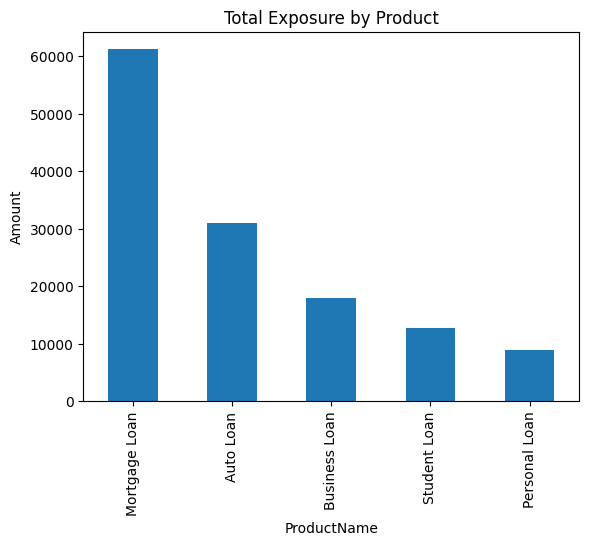

In [13]:
portfolio["TotalOutstanding"].plot(kind="bar")
plt.title("Total Exposure by Product")
plt.ylabel("Amount")
plt.show()

In [14]:
portfolio = df.groupby("ProductName").agg({
    "LoanID": "count",
    "TotalOutstanding": "sum",
    "AtRisk": "mean",
    "NPL": "mean",
    "AverageDPD": "mean"
}).rename(columns={
    "LoanID": "LoanCount",
    "AtRisk": "AtRiskRate",
    "NPL": "NPLRate",
    "AverageDPD": "AvgDPD"
})

portfolio["AtRiskRate"] = portfolio["AtRiskRate"] * 100
portfolio["NPLRate"] = portfolio["NPLRate"] * 100

portfolio = portfolio.rename(columns={
    "AtRiskRate": "AtRiskRate (%)",
    "NPLRate": "NPLRate (%)"
})

portfolio["AtRiskRate (%)"] = portfolio["AtRiskRate (%)"].round(2)
portfolio["NPLRate (%)"] = portfolio["NPLRate (%)"].round(2)
portfolio["AvgDPD"] = portfolio["AvgDPD"].round(1)

portfolio = portfolio.sort_values(by="TotalOutstanding", ascending=False)

portfolio

,LoanCount,TotalOutstanding,AtRiskRate (%),NPLRate (%),AvgDPD
ProductName,,,,,
Mortgage Loan,2,61200.0,50.00,50.00,179.0
Auto Loan,2,31080.0,100.00,100.00,154.5
Business Loan,1,18000.0,100.00,100.00,142.0
Student Loan,3,12700.0,33.33,33.33,48.7
Personal Loan,6,8920.0,33.33,0.00,34.0


## Which product has the most money AND is risky

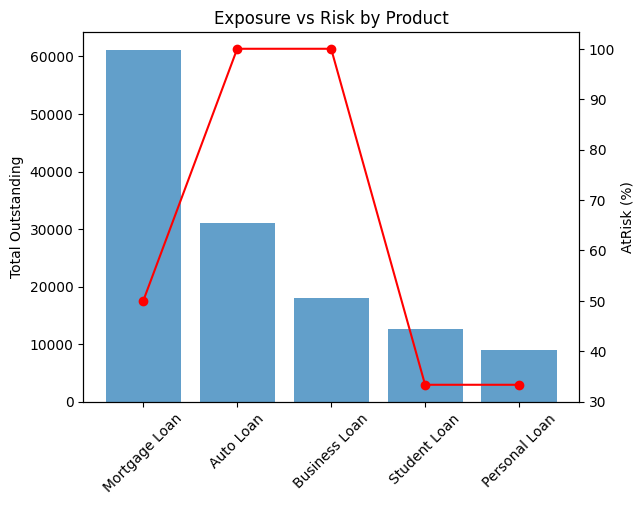

In [15]:
fig, ax1 = plt.subplots()

# Bar chart → exposure
ax1.bar(portfolio.index, portfolio["TotalOutstanding"], alpha=0.7)
ax1.set_ylabel("Total Outstanding")
ax1.set_title("Exposure vs Risk by Product")

# Rotate labels
plt.xticks(rotation=45)

# Second axis → risk %
ax2 = ax1.twinx()
ax2.plot(portfolio.index, portfolio["AtRiskRate (%)"], color="red", marker="o")
ax2.set_ylabel("AtRisk (%)")

plt.show()

# Risky loans

## filter

In [16]:
df_risk = df[df["AtRisk"] == 1]

In [17]:
df_risk.head(20)

,DateID,Year,Month,ProductName,LoanID,ProductID,AverageDPD,MaximumDPD,TotalOutstanding,NPL,AtRisk
1,20260427,2026,4,Student Loan,2,40,59.0,123,3100.0,1,1
2,20260427,2026,4,Personal Loan,3,20,117.0,158,5300.0,0,1
3,20260427,2026,4,Auto Loan,4,30,166.0,208,12400.0,1,1
5,20260427,2026,4,Mortgage Loan,6,10,358.0,398,61200.0,1,1
6,20260427,2026,4,Personal Loan,7,20,87.0,128,3620.0,0,1
8,20260427,2026,4,Business Loan,9,50,142.0,214,18000.0,1,1
9,20260427,2026,4,Auto Loan,10,30,143.0,184,18680.0,1,1


In [18]:
df_risk.shape

(7, 11)

In [19]:
risk_portfolio = df_risk.groupby("ProductName").agg({
    "LoanID": "count",
    "TotalOutstanding": "sum",
    "AverageDPD": "mean"
}).rename(columns={
    "LoanID": "RiskyLoanCount",
    "AverageDPD": "AvgDPD_Risky"
}).sort_values(by="TotalOutstanding", ascending=False)

risk_portfolio

,RiskyLoanCount,TotalOutstanding,AvgDPD_Risky
ProductName,,,
Mortgage Loan,1,61200.0,358.0
Auto Loan,2,31080.0,154.5
Business Loan,1,18000.0,142.0
Personal Loan,2,8920.0,102.0
Student Loan,1,3100.0,59.0


In [20]:
portfolio_analysis = df.groupby("ProductName").agg({
    "TotalOutstanding": "sum",
    "AtRisk": "mean"
})

portfolio_analysis["RiskExposure"] = (
    portfolio_analysis["TotalOutstanding"] * portfolio_analysis["AtRisk"]
)

portfolio_analysis.sort_values(by="RiskExposure", ascending=False)

portfolio_analysis

,TotalOutstanding,AtRisk,RiskExposure
ProductName,,,
Auto Loan,31080.0,1.000000,31080.000000
Business Loan,18000.0,1.000000,18000.000000
Mortgage Loan,61200.0,0.500000,30600.000000
Personal Loan,8920.0,0.333333,2973.333333
Student Loan,12700.0,0.333333,4233.333333


- Auto Loan
all loans are bad
guaranteed problem
- Mortgage Loan
only half are bad
but large exposure

# investigate Auto Loans (the worst case)

In [21]:
df[df["ProductName"] == "Auto Loan"]

,DateID,Year,Month,ProductName,LoanID,ProductID,AverageDPD,MaximumDPD,TotalOutstanding,NPL,AtRisk
3,20260427,2026,4,Auto Loan,4,30,166.0,208,12400.0,1,1
9,20260427,2026,4,Auto Loan,10,30,143.0,184,18680.0,1,1


compare Auto Loan with Mortgage Loan

In [22]:
df[df["ProductName"].isin(["Auto Loan", "Mortgage Loan"])]

,DateID,Year,Month,ProductName,LoanID,ProductID,AverageDPD,MaximumDPD,TotalOutstanding,NPL,AtRisk
3,20260427,2026,4,Auto Loan,4,30,166.0,208,12400.0,1,1
4,20260427,2026,4,Mortgage Loan,5,10,0.0,0,0.0,0,0
5,20260427,2026,4,Mortgage Loan,6,10,358.0,398,61200.0,1,1
9,20260427,2026,4,Auto Loan,10,30,143.0,184,18680.0,1,1


# Create a “risk flag” column

# Risk Classification

Loans are classified into:
- Low Risk
- Moderate Risk
- Severe Risk

Classification is based on:
- Non-performing loan status (NPL)
- AtRisk indicators
- Delinquency severity


In [23]:
df["RiskCategory"] = df.apply(
    lambda row: "Severe" if row["AverageDPD"] > 180 else
                "Moderate" if row["AverageDPD"] > 60 else
                "Low",
    axis=1
)

df

,DateID,Year,Month,ProductName,LoanID,ProductID,AverageDPD,MaximumDPD,TotalOutstanding,NPL,AtRisk,RiskCategory
0,20260427,2026,4,Student Loan,1,40,50.0,92,4200.0,0,0,Low
1,20260427,2026,4,Student Loan,2,40,59.0,123,3100.0,1,1,Low
2,20260427,2026,4,Personal Loan,3,20,117.0,158,5300.0,0,1,Moderate
3,20260427,2026,4,Auto Loan,4,30,166.0,208,12400.0,1,1,Moderate
4,20260427,2026,4,Mortgage Loan,5,10,0.0,0,0.0,0,0,Low
5,20260427,2026,4,Mortgage Loan,6,10,358.0,398,61200.0,1,1,Severe
6,20260427,2026,4,Personal Loan,7,20,87.0,128,3620.0,0,1,Moderate
7,20260427,2026,4,Student Loan,8,40,37.0,66,5400.0,0,0,Low
8,20260427,2026,4,Business Loan,9,50,142.0,214,18000.0,1,1,Moderate
9,20260427,2026,4,Auto Loan,10,30,143.0,184,18680.0,1,1,Moderate


In [24]:
df.groupby(["ProductName", "RiskCategory"])["LoanID"].count()

ProductName    RiskCategory
Auto Loan      Moderate        2
Business Loan  Moderate        1
Mortgage Loan  Low             1
               Severe          1
Personal Loan  Low             4
               Moderate        2
Student Loan   Low             3
Name: LoanID, dtype: int64

In [25]:
df["RiskCategory"] = df.apply(
    lambda row: "Severe" if row["NPL"] == 1 else
                "Moderate" if row["AtRisk"] == 1 else
                "Low",
    axis=1
)
df

,DateID,Year,Month,ProductName,LoanID,ProductID,AverageDPD,MaximumDPD,TotalOutstanding,NPL,AtRisk,RiskCategory
0,20260427,2026,4,Student Loan,1,40,50.0,92,4200.0,0,0,Low
1,20260427,2026,4,Student Loan,2,40,59.0,123,3100.0,1,1,Severe
2,20260427,2026,4,Personal Loan,3,20,117.0,158,5300.0,0,1,Moderate
3,20260427,2026,4,Auto Loan,4,30,166.0,208,12400.0,1,1,Severe
4,20260427,2026,4,Mortgage Loan,5,10,0.0,0,0.0,0,0,Low
5,20260427,2026,4,Mortgage Loan,6,10,358.0,398,61200.0,1,1,Severe
6,20260427,2026,4,Personal Loan,7,20,87.0,128,3620.0,0,1,Moderate
7,20260427,2026,4,Student Loan,8,40,37.0,66,5400.0,0,0,Low
8,20260427,2026,4,Business Loan,9,50,142.0,214,18000.0,1,1,Severe
9,20260427,2026,4,Auto Loan,10,30,143.0,184,18680.0,1,1,Severe


In [26]:
df.groupby(["ProductName", "RiskCategory"])["LoanID"].count()

ProductName    RiskCategory
Auto Loan      Severe          2
Business Loan  Severe          1
Mortgage Loan  Low             1
               Severe          1
Personal Loan  Low             4
               Moderate        2
Student Loan   Low             2
               Severe          1
Name: LoanID, dtype: int64

## money at risk

In [27]:
df_severe = df[df["RiskCategory"] == "Severe"]

df_severe.groupby("ProductName")["TotalOutstanding"] \
    .sum() \
    .sort_values(ascending=False)

ProductName
Mortgage Loan    61200.0
Auto Loan        31080.0
Business Loan    18000.0
Student Loan      3100.0
Name: TotalOutstanding, dtype: float64

# summary

# Severe Exposure Analysis

This section identifies how much portfolio exposure is concentrated in severe-risk loans.

The analysis focuses on:
- total exposure
- severe exposure
- share of severe exposure by product


In [28]:
final_view = pd.DataFrame({
    "TotalExposure": df.groupby("ProductName")["TotalOutstanding"].sum(),
    "SevereExposure": df_severe.groupby("ProductName")["TotalOutstanding"].sum()
})

final_view["SevereShare (%)"] = (
    final_view["SevereExposure"] / final_view["TotalExposure"] * 100
).round(2)

final_view.sort_values(by="SevereExposure", ascending=False)
final_view = final_view.fillna(0)
final_view

,TotalExposure,SevereExposure,SevereShare (%)
ProductName,,,
Auto Loan,31080.0,31080.0,100.00
Business Loan,18000.0,18000.0,100.00
Mortgage Loan,61200.0,61200.0,100.00
Personal Loan,8920.0,0.0,0.00
Student Loan,12700.0,3100.0,24.41


# Portfolio Trend Analysis

This section introduces a tactical time dimension to the portfolio analysis.

The objective is to monitor how portfolio exposure and risk indicators evolve over time.

The analysis focuses on:
- exposure trend by month
- NPL trend by month
- AtRisk trend by month

Trend analysis helps identify:
- deterioration of portfolio quality
- increasing delinquency
- concentration of risk over time


In [29]:
trend_analysis = df.groupby(["Year", "Month"]).agg({
    "TotalOutstanding": "sum",
    "NPL": "mean",
    "AtRisk": "mean"
}).reset_index()

trend_analysis["NPL (%)"] = (trend_analysis["NPL"] * 100).round(2)
trend_analysis["AtRisk (%)"] = (trend_analysis["AtRisk"] * 100).round(2)

trend_analysis


,Year,Month,TotalOutstanding,NPL,AtRisk,NPL (%),AtRisk (%)
0,2026,4,131900.0,0.357143,0.5,35.71,50.0


## Portfolio Exposure and Risk Trend

The following charts visualize:
- total portfolio exposure
- non-performing loan ratio
- at-risk loan ratio

These indicators support tactical portfolio monitoring and early risk detection.


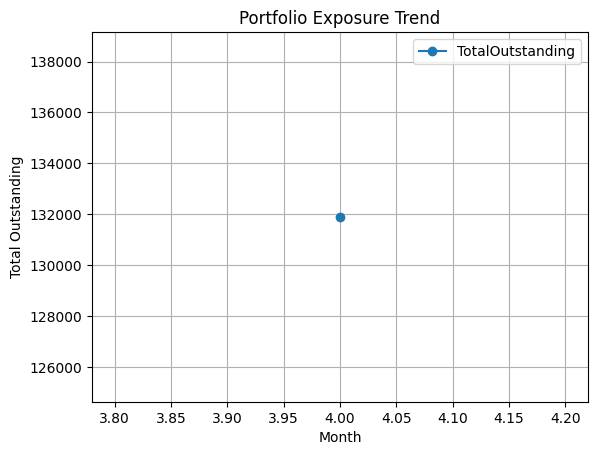

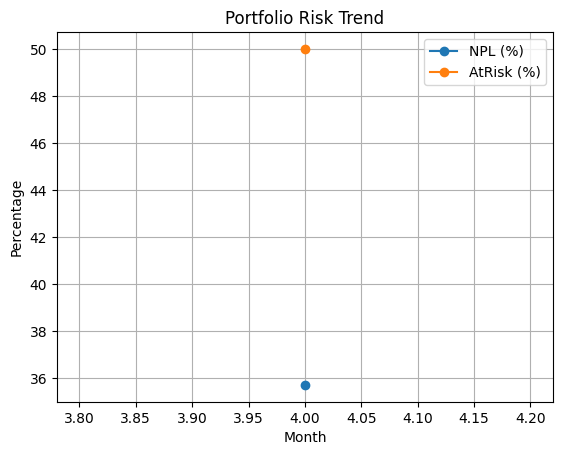

In [30]:
import matplotlib.pyplot as plt

# Exposure trend
trend_analysis.plot(
    x="Month",
    y="TotalOutstanding",
    kind="line",
    marker="o",
    title="Portfolio Exposure Trend"
)

plt.ylabel("Total Outstanding")
plt.grid(True)
plt.show()

# Risk trend
trend_analysis.plot(
    x="Month",
    y=["NPL (%)", "AtRisk (%)"],
    kind="line",
    marker="o",
    title="Portfolio Risk Trend"
)

plt.ylabel("Percentage")
plt.grid(True)
plt.show()


## Trend Analysis Interpretation

Trend analysis enables tactical monitoring of portfolio dynamics over time.

Key indicators:
- increasing exposure may indicate portfolio growth
- increasing NPL ratios may indicate deteriorating portfolio quality
- increasing AtRisk ratios may signal future default growth

In a production-scale dataset, this analysis would help:
- identify early warning trends
- adjust lending strategy
- optimize risk monitoring procedures


# Conclusions and Tactical Recommendations

## Key Findings

### Mortgage Loans
- Highest severe exposure in the portfolio
- Significant financial impact concentrated in a single severe loan
- Represents concentrated portfolio risk

### Auto Loans
- 100% of exposure classified as severe
- Indicates systemic portfolio quality issues
- Requires review of approval and monitoring policies

### Personal Loans
- Lowest portfolio risk
- No severe exposure detected
- Represents the healthiest loan product segment

### Student Loans
- Moderate portfolio risk
- Limited severe exposure

---

## Tactical Recommendations

### Immediate Actions
- Investigate high-risk Mortgage Loan cases
- Review overdue loans with extremely high DPD values

### Product-Level Improvements
- Reassess Auto Loan approval rules and customer eligibility criteria
- Improve risk monitoring for products with high severe exposure

### Portfolio Monitoring
- Continuously monitor:
  - DPD trends
  - NPL ratios
  - severe exposure share
  - product-level performance

---

## Analysis Limitations

- Small dataset sample size
- Limited historical trend analysis
- No customer demographic segmentation included in this notebook
- Results are indicative and not statistically conclusive
